
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/11_Lab_LagevineII_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [20]:
N = 8
Zr = stats.norm(loc=0, scale=1)
Z = Zr.rvs(size=N*N)

In [21]:
sigma=0.5
epsilon = sigma*Z
e = epsilon

In [22]:
np.std(epsilon)

np.float64(0.43501458316012204)

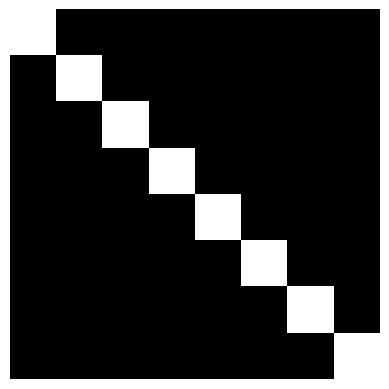

In [23]:
X = np.eye(N)
x = X.flatten()  # Vector con N² píxeles

plt.imshow(x.reshape(N, N), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.show()

ENTRADA: imágenes originales y niveles de ruido σ

Normalizar las imágenes
Separar datos de entrenamiento y evaluación
Inicializar los parámetros θ del modelo

REPETIR hasta completar el entrenamiento:
    Seleccionar un lote de imágenes originales x
    Seleccionar un nivel de ruido σ

    Generar ruido nuevo: e = σ · Normal(0, I)
    Construir imágenes perturbadas: y = x + e

    Calcular el campo objetivo: S_objetivo = −e / σ²
    Predecir el campo: S_predicho = sθ(y, σ)

    Pérdida = ½ · promedio(||S_predicho − S_objetivo||²)
    Actualizar θ usando el gradiente de la pérdida

Evaluar el modelo con los datos reservados
SALIDA: campo aprendido sθ(y, σ)

In [24]:
#x = np.array([0.2, 0.8, 0.4, 0.6])
#e

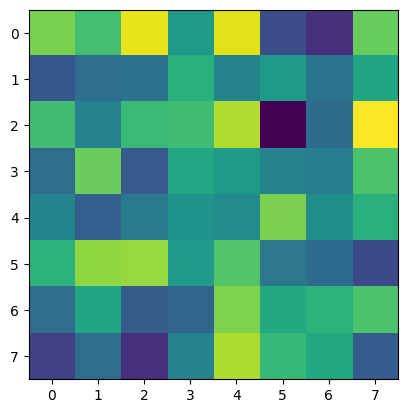

In [25]:
# Ruuido gaussian
Sobjetivo = -e/sigma**2
plt.imshow(Sobjetivo.reshape(N, N))

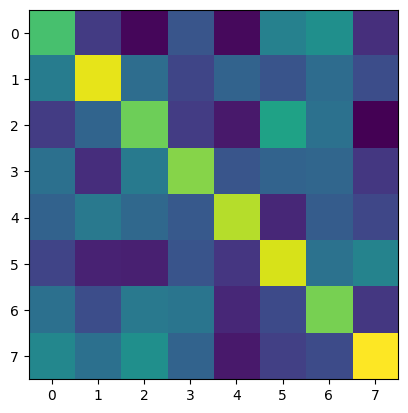

In [26]:
xp = x + e*sigma
plt.imshow(xp.reshape(8,8))

In [54]:
# Construir algoritmo

sigma=0.2
epsilon = sigma*Z
e = epsilon

A = 0.0
B = 0.0
alphaA = 0.01
alphaB = 0.5

rng = np.random.default_rng(42)

for i in range(0, 50000):
    e = rng.normal(0, sigma, size=x.shape)
    Sobjetivo = -e/sigma**2 
    xp = x + e
    #modelo
    Z = A*xp + B

    Spredicjo = Z.copy()
    error = Spredicjo - Sobjetivo 
    #fun perdida
    Loss = 0.5*np.mean(error**2)
    gradA = np.mean(error*xp)
    gradB = error/x.size
    A = A - alphaA*gradA    
    B = B - alphaB*gradB
    
print(Loss)



1.4953405688344764e-14


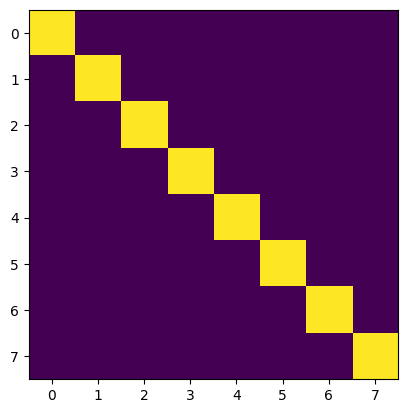

In [55]:
Y = xp + sigma**2*Spredicjo
plt.imshow(Y.reshape(8, 8))



ENTRADA: imagen perturbada y, nivel de ruido σ,
         campo aprendido sθ

Calcular el campo: S = sθ(y, σ)

Estimar la imagen limpia:
    x_estimada = y + σ² · S

Si conocemos la imagen original:
    Comparar la estimación con ella
    Calcular el error de recuperación

SALIDA: imagen limpia estimada

In [56]:
rng_prueba = np.random.default_rng(123)

e_prueba = rng_prueba.normal(0, sigma, size=x.shape)
x_prueba = x + e_prueba

# 2. Evaluar el campo aprendido.
S_prueba = A * x_prueba + B

# 3. Recuperar la imagen usando ese campo.
x_recuperado = x_prueba + sigma**2 * S_prueba

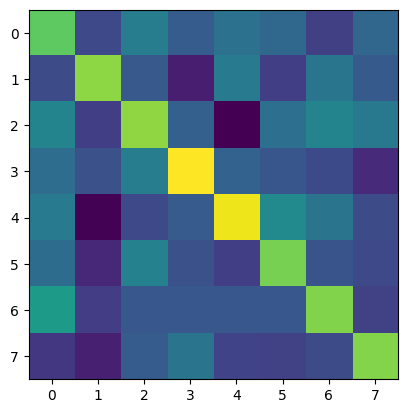

In [57]:
plt.imshow(x_prueba.reshape(8,8))

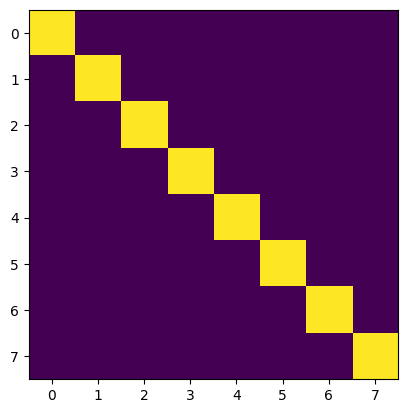

In [58]:
plt.imshow(x_recuperado.reshape(8,8))

# Langevine

ENTRADA: campo aprendido, niveles σ de mayor a menor,
         número de pasos K y constante pequeña c

Inicializar desde ruido:
    Y = μ + σ_max · Normal(0, I)
    μ es la media de las imágenes de entrenamiento

PARA cada nivel σ, desde σ_max hasta σ_min:
    Elegir el paso: h = c · σ²

    REPETIR K veces:
        Calcular el campo: S = sθ(Y, σ)
        Generar ruido nuevo: Z = Normal(0, I)

        Actualizar mediante Langevin:
            Y = Y + h · S + √(2h) · Z

Opcionalmente aplicar la recuperación final:
    Y = Y + σ_min² · sθ(Y, σ_min)

SALIDA: imagen generada

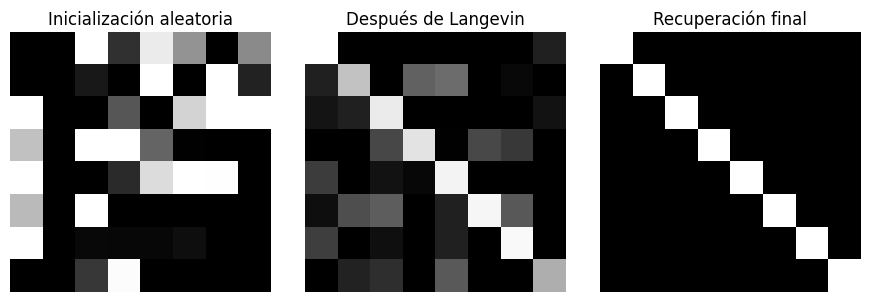

In [59]:
rng_generacion = np.random.default_rng(123)

# Inicialización independiente de la imagen original.
Y = rng_generacion.normal(0, 1, size=x.shape)
Y_inicial = Y.copy()

dt = 0.001  # Para sigma = 0.1 y A cercano a -100.
n_pasos = 1000

# Aquí entra Langevin.
for paso in range(n_pasos):

    S = A * Y + B
    Z = rng_generacion.normal(size=Y.shape)
    Y = Y + dt * S + np.sqrt(2 * dt) * Z

# Recuperación final: es una operación distinta.
Y_recuperada = Y + sigma**2 * (A * Y + B)

fig, ejes = plt.subplots(1, 3, figsize=(9, 3))

comparaciones = [
    (Y_inicial, "Inicialización aleatoria"),
    (Y, "Después de Langevin"),
    (Y_recuperada, "Recuperación final")
]

for eje, (imagen, titulo) in zip(ejes, comparaciones):
    eje.imshow(
        np.clip(imagen.reshape(N, N), 0, 1),
        cmap="gray", vmin=0, vmax=1
    )
    eje.set_title(titulo)
    eje.axis("off")

plt.tight_layout()
plt.show()

# Caso con más imagenes

In [1]:
%pip -q install datasets


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

datos = load_dataset(
    "uoft-cs/cifar10",
    split="train",
    streaming=True
)
perros = []

for ejemplo in datos:
    if ejemplo["label"] == 5:  # Perro
        perros.append(np.array(ejemplo["img"].convert("RGB")))

        if len(perros) % 25 == 0:
            print(f"Cargados: {len(perros)} perros")

        if len(perros) == 1000:
            break


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargados: 25 perros
Cargados: 50 perros
Cargados: 75 perros
Cargados: 100 perros
Cargados: 125 perros
Cargados: 150 perros
Cargados: 175 perros
Cargados: 200 perros
Cargados: 225 perros
Cargados: 250 perros
Cargados: 275 perros
Cargados: 300 perros
Cargados: 325 perros
Cargados: 350 perros
Cargados: 375 perros
Cargados: 400 perros
Cargados: 425 perros
Cargados: 450 perros
Cargados: 475 perros
Cargados: 500 perros
Cargados: 525 perros
Cargados: 550 perros
Cargados: 575 perros
Cargados: 600 perros
Cargados: 625 perros
Cargados: 650 perros
Cargados: 675 perros
Cargados: 700 perros
Cargados: 725 perros
Cargados: 750 perros
Cargados: 775 perros
Cargados: 800 perros
Cargados: 825 perros
Cargados: 850 perros
Cargados: 875 perros
Cargados: 900 perros
Cargados: 925 perros
Cargados: 950 perros
Cargados: 975 perros
Cargados: 1000 perros


Forma: (1000, 32, 32, 3)


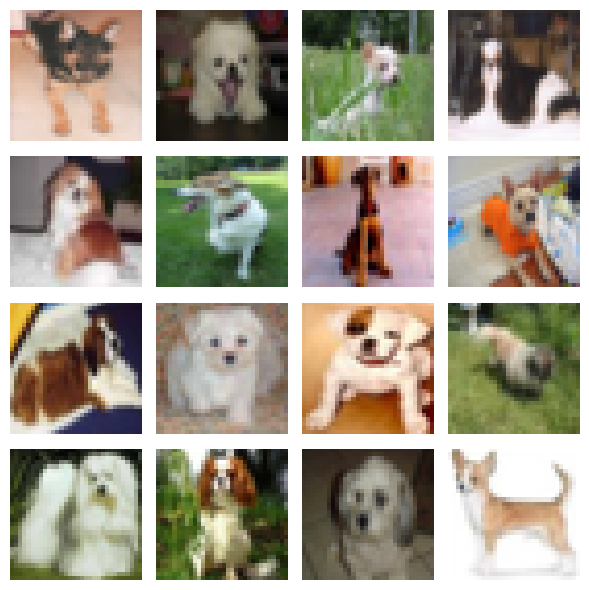

In [6]:
X_perros = np.stack(perros)
print("Forma:", X_perros.shape)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, imagen in zip(axes.ravel(), X_perros[:16]):
    ax.imshow(imagen)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X_entrenamiento = X_perros.astype(np.float32) / 127.5 - 1.0

In [8]:
rng = np.random.default_rng(42)
sigma = 0.3

# Ruido independiente para cada imagen, píxel y canal
epsilon = rng.normal(
    loc=0,
    scale=sigma,
    size=X_entrenamiento.shape
).astype(np.float32)

X_ruidosas = X_entrenamiento + epsilon

# Campo objetivo para entrenar
S_objetivo = -epsilon / sigma**2

print("Imágenes limpias:", X_entrenamiento.shape)
print("Imágenes ruidosas:", X_ruidosas.shape)
print("Score objetivo:", S_objetivo.shape)

Imágenes limpias: (1000, 32, 32, 3)
Imágenes ruidosas: (1000, 32, 32, 3)
Score objetivo: (1000, 32, 32, 3)


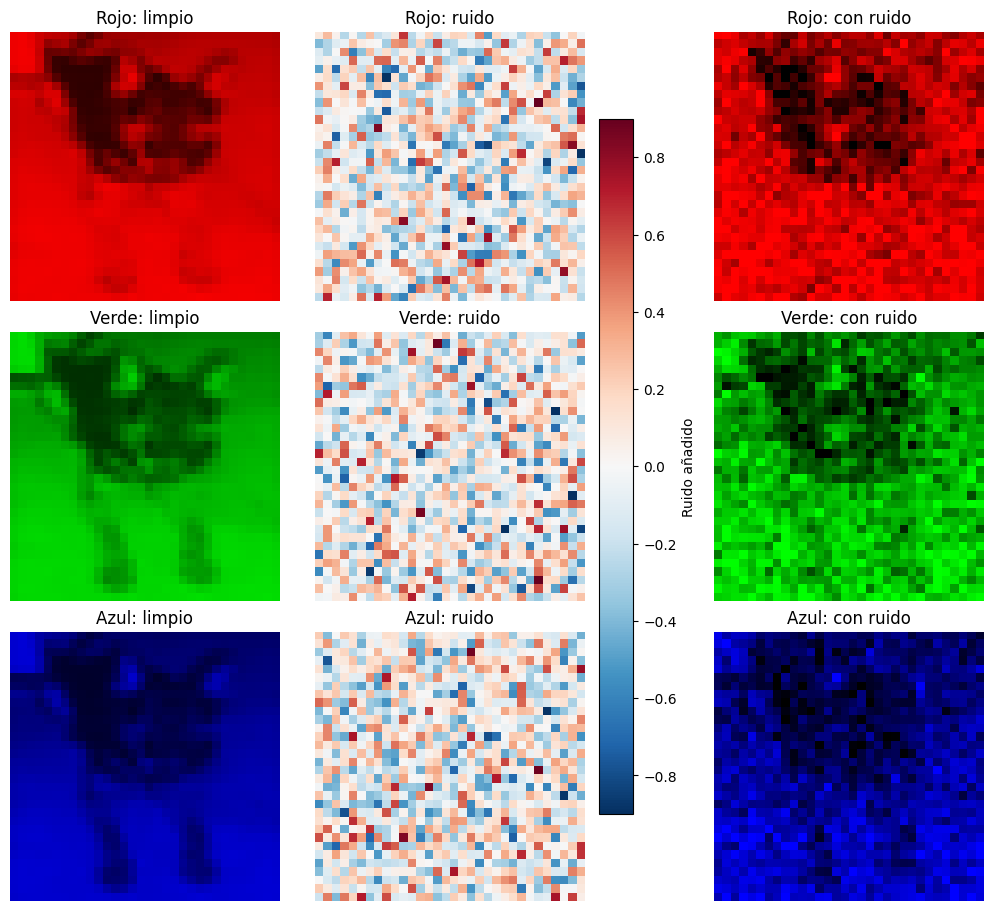

In [9]:
i = 0
limpia = np.clip((X_entrenamiento[i] + 1) / 2, 0, 1)
ruidosa = np.clip((X_ruidosas[i] + 1) / 2, 0, 1)

nombres = ["Rojo", "Verde", "Azul"]

fig, axes = plt.subplots(
    3, 3, figsize=(10, 9), constrained_layout=True
)

for canal, nombre in enumerate(nombres):

    # Mostrar únicamente este canal en su color
    limpia_canal = np.zeros_like(limpia)
    limpia_canal[:, :, canal] = limpia[:, :, canal]

    ruidosa_canal = np.zeros_like(ruidosa)
    ruidosa_canal[:, :, canal] = ruidosa[:, :, canal]

    axes[canal, 0].imshow(limpia_canal)
    axes[canal, 0].set_title(f"{nombre}: limpio")

    im = axes[canal, 1].imshow(
        epsilon[i, :, :, canal],
        cmap="RdBu_r",
        vmin=-3 * sigma,
        vmax=3 * sigma
    )
    axes[canal, 1].set_title(f"{nombre}: ruido")

    axes[canal, 2].imshow(ruidosa_canal)
    axes[canal, 2].set_title(f"{nombre}: con ruido")

for ax in axes.ravel():
    ax.axis("off")

fig.colorbar(
    im,
    ax=axes[:, 1].tolist(),
    shrink=0.8,
    label="Ruido añadido"
)

plt.show()

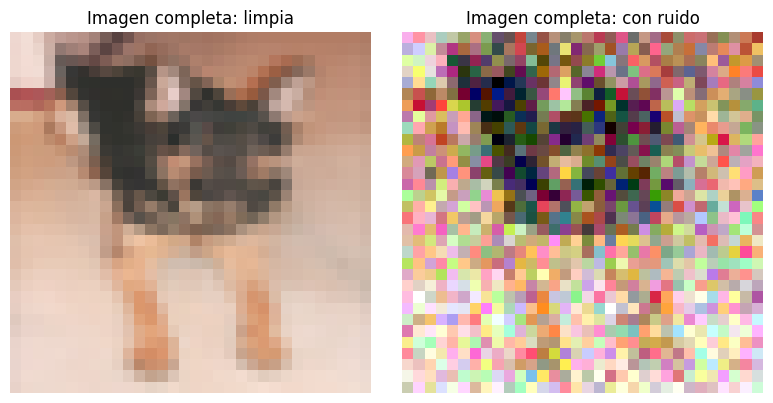

In [ ]:
i = 0
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(
    np.clip((X_entrenamiento[i] + 1) / 2, 0, 1)
)
axes[0].set_title("Imagen completa: limpia")
axes[1].imshow(
    np.clip((X_ruidosas[i] + 1) / 2, 0, 1)
)
axes[1].set_title("Imagen completa: con ruido")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# X_entrenamiento ya debe estar normalizado a [-1, 1]
corte = int(0.8 * len(X_entrenamiento))
datos = X_entrenamiento[:corte]
evaluacion = X_entrenamiento[corte:]

# Parámetros iniciales
a = 0.0
B = np.zeros_like(datos[0])

D = B.size  # Número de componentes: píxeles × canales

lr_a = 0.01
lr_B = lr_a * D  # Compensa el promedio sobre D componentes

Paso 200: pérdida = 4.3932
Paso 400: pérdida = 4.0584
Paso 600: pérdida = 4.0082
Paso 800: pérdida = 4.1237
Paso 1000: pérdida = 3.9600
Paso 1200: pérdida = 4.0454
Paso 1400: pérdida = 4.1441
Paso 1600: pérdida = 4.0803
Paso 1800: pérdida = 4.2598
Paso 2000: pérdida = 3.9349
a aprendido: -3.0381432


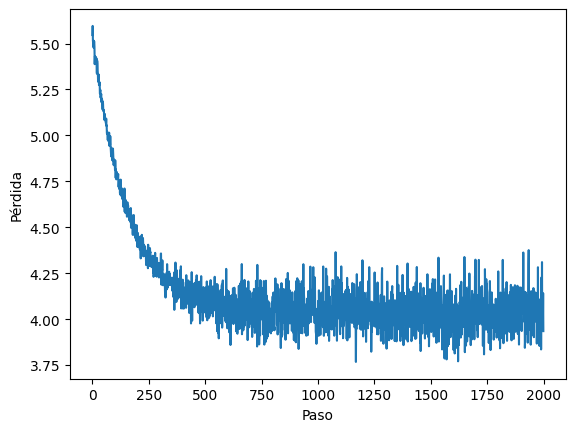

In [ ]:
n_pasos = 2000
historia = []
for paso in range(n_pasos):
    # Seleccionar un grupo de imágenes
    indices = rng.integers(0, len(datos), size=32)
    X = datos[indices]
    # Agregar ruido nuevo
    epsilon = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    Y = X + epsilon
    # Score objetivo y score predicho
    S_objetivo = -epsilon / sigma**2

    S_predicho = a * Y + B



    error = S_predicho - S_objetivo
    loss = 0.5 * np.mean(error**2)
    # Gradientes de esa pérdida
    grad_a = np.mean(error * Y)
    grad_B = np.mean(error, axis=0) / D

    # Actualizar los parámetros
    a -= lr_a * grad_a
    B -= lr_B * grad_B

    historia.append(loss)

    if (paso + 1) % 200 == 0:
        print(f"Paso {paso + 1}: pérdida = {loss:.4f}")

print("a aprendido:", a)

plt.plot(historia)
plt.xlabel("Paso")
plt.ylabel("Pérdida")
plt.show()

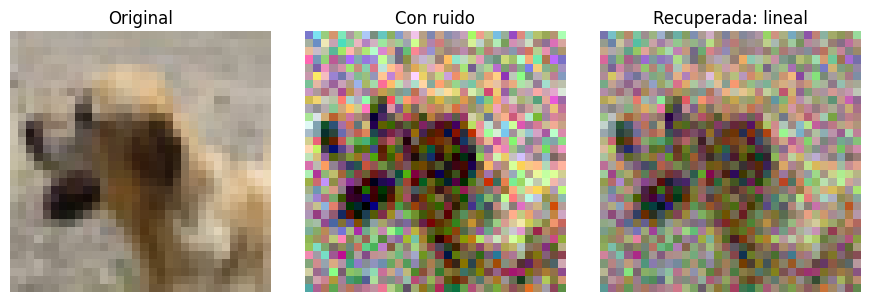

MSE con ruido: 0.0881564
MSE recuperada: 0.05862242


In [ ]:
X = evaluacion[4]

epsilon = rng.normal(
    0, sigma, size=X.shape
).astype(np.float32)

Y = X + epsilon

S_predicho = a * Y + B
X_recuperada = Y + sigma**2 * S_predicho

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

imagenes = [X, Y, X_recuperada]
titulos = ["Original", "Con ruido", "Recuperada: lineal"]

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(np.clip((imagen + 1) / 2, 0, 1))
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("MSE con ruido:", np.mean((Y - X)**2))
print("MSE recuperada:", np.mean((X_recuperada - X)**2))

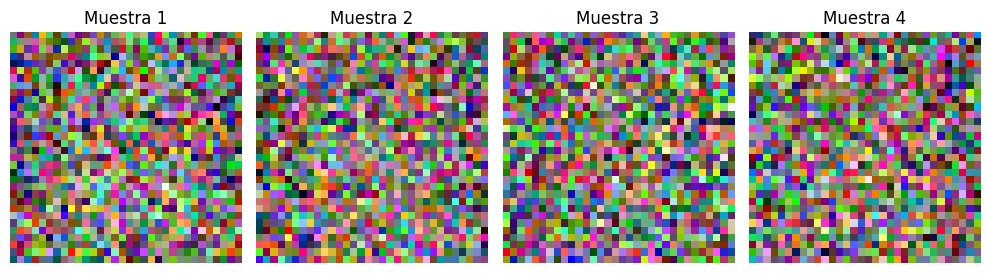

In [ ]:
rng = np.random.default_rng(123)

if a >= 0:
    raise ValueError("Necesitamos a < 0 para tener una distribución estable.")

# Cuatro imágenes inicializadas con ruido puro
Y = rng.normal(size=(4,) + B.shape).astype(np.float32)

dt = 0.05 / abs(a)  # Paso pequeño respecto a la escala del campo

for paso in range(1000):
    S = a * Y + B
    Z = rng.normal(size=Y.shape)
    Y = Y + dt * S + np.sqrt(2 * dt) * Z

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(np.clip((Y[i] + 1) / 2, 0, 1))
    ax.set_title(f"Muestra {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
rng = np.random.default_rng(123)

if a >= 0:
    raise ValueError("Necesitamos a < 0.")

n_muestras = 200

Y = rng.normal(
    size=(n_muestras,) + B.shape
).astype(np.float32)

dt = 0.05 / abs(a)

for paso in range(1000):
    S = a * Y + B
    Z = rng.normal(size=Y.shape).astype(np.float32)

    Y = Y + dt * S + np.sqrt(2 * dt) * Z
# Promedio de las muestras, sin recortar sus valores
promedio = Y.mean(axis=0)
# Promedio esperado del modelo lineal
media_modelo = -B / a

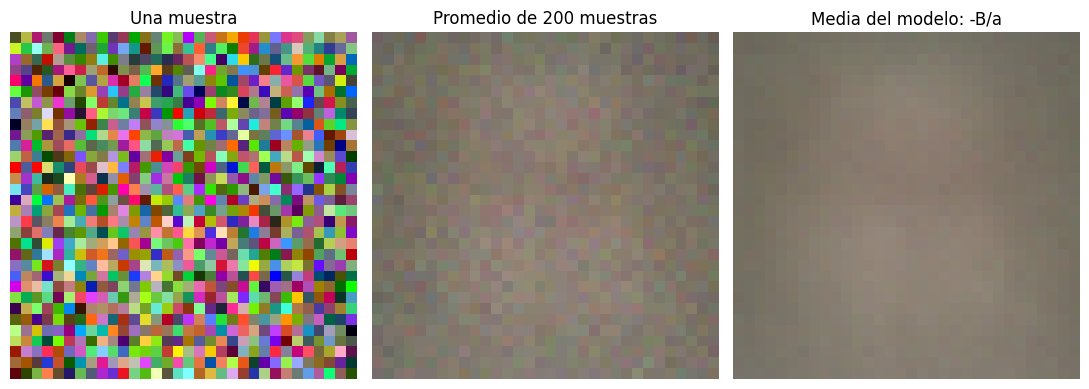

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

imagenes = [Y[0], promedio, media_modelo]
titulos = [
    "Una muestra",
    f"Promedio de {n_muestras} muestras",
    "Media del modelo: -B/a"
]

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(np.clip((imagen + 1) / 2, 0, 1))
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
%pip install -q pillow numpy matplotlib


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
try:
    from datasets import load_dataset
except ImportError:
    %pip install -q datasets
    from datasets import load_dataset

from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

N = 100
TAMANO = 64

carpeta = Path("flores_64")
carpeta.mkdir(exist_ok=True)


def cargar_flores(n=100, tamano=64):
    """Carga imágenes del dataset Oxford Flowers con un fallback robusto."""
    try:
        ds = load_dataset("nkirschi/oxford-flowers", split=f"train[:{n}]")
        imagenes = []

        for ejemplo in ds:
            img = ejemplo["image"]

            if isinstance(img, dict):
                img = Image.open(BytesIO(img["bytes"])) if "bytes" in img else Image.open(BytesIO(img.get("content", b"")))
            elif not isinstance(img, Image.Image):
                img = Image.fromarray(np.asarray(img))

            img = img.convert("RGB")
            img = ImageOps.fit(img, (tamano, tamano))
            imagenes.append(np.asarray(img, dtype=np.float32) / 255.0)

        return np.stack(imagenes)

    except Exception as e:
        print(f"Fallo al usar datasets: {e}")
        print("Usando fallback HTTP...")

        import json
        from urllib.request import urlopen

        url = (
            "https://datasets-server.huggingface.co/rows?"
            "dataset=nkirschi/oxford-flowers&config=default&split=train"
            f"&offset=0&length={n}"
        )

        with urlopen(url, timeout=60) as respuesta:
            filas = json.load(respuesta)["rows"]

        imagenes = []
        for i, fila in enumerate(filas):
            archivo = carpeta / f"flor_{i:03d}.png"

            if not archivo.exists():
                with urlopen(fila["row"]["image"]["src"], timeout=60) as respuesta:
                    imagen = Image.open(BytesIO(respuesta.read())).convert("RGB")

                imagen = ImageOps.fit(imagen, (tamano, tamano))
                imagen.save(archivo)

            with Image.open(archivo) as imagen:
                imagenes.append(np.asarray(imagen, dtype=np.float32) / 255.0)

        return np.stack(imagenes)


imagenes = cargar_flores(N, TAMANO)
print("Forma:", imagenes.shape)
print("Rango:", imagenes.min(), imagenes.max())


KeyboardInterrupt: 

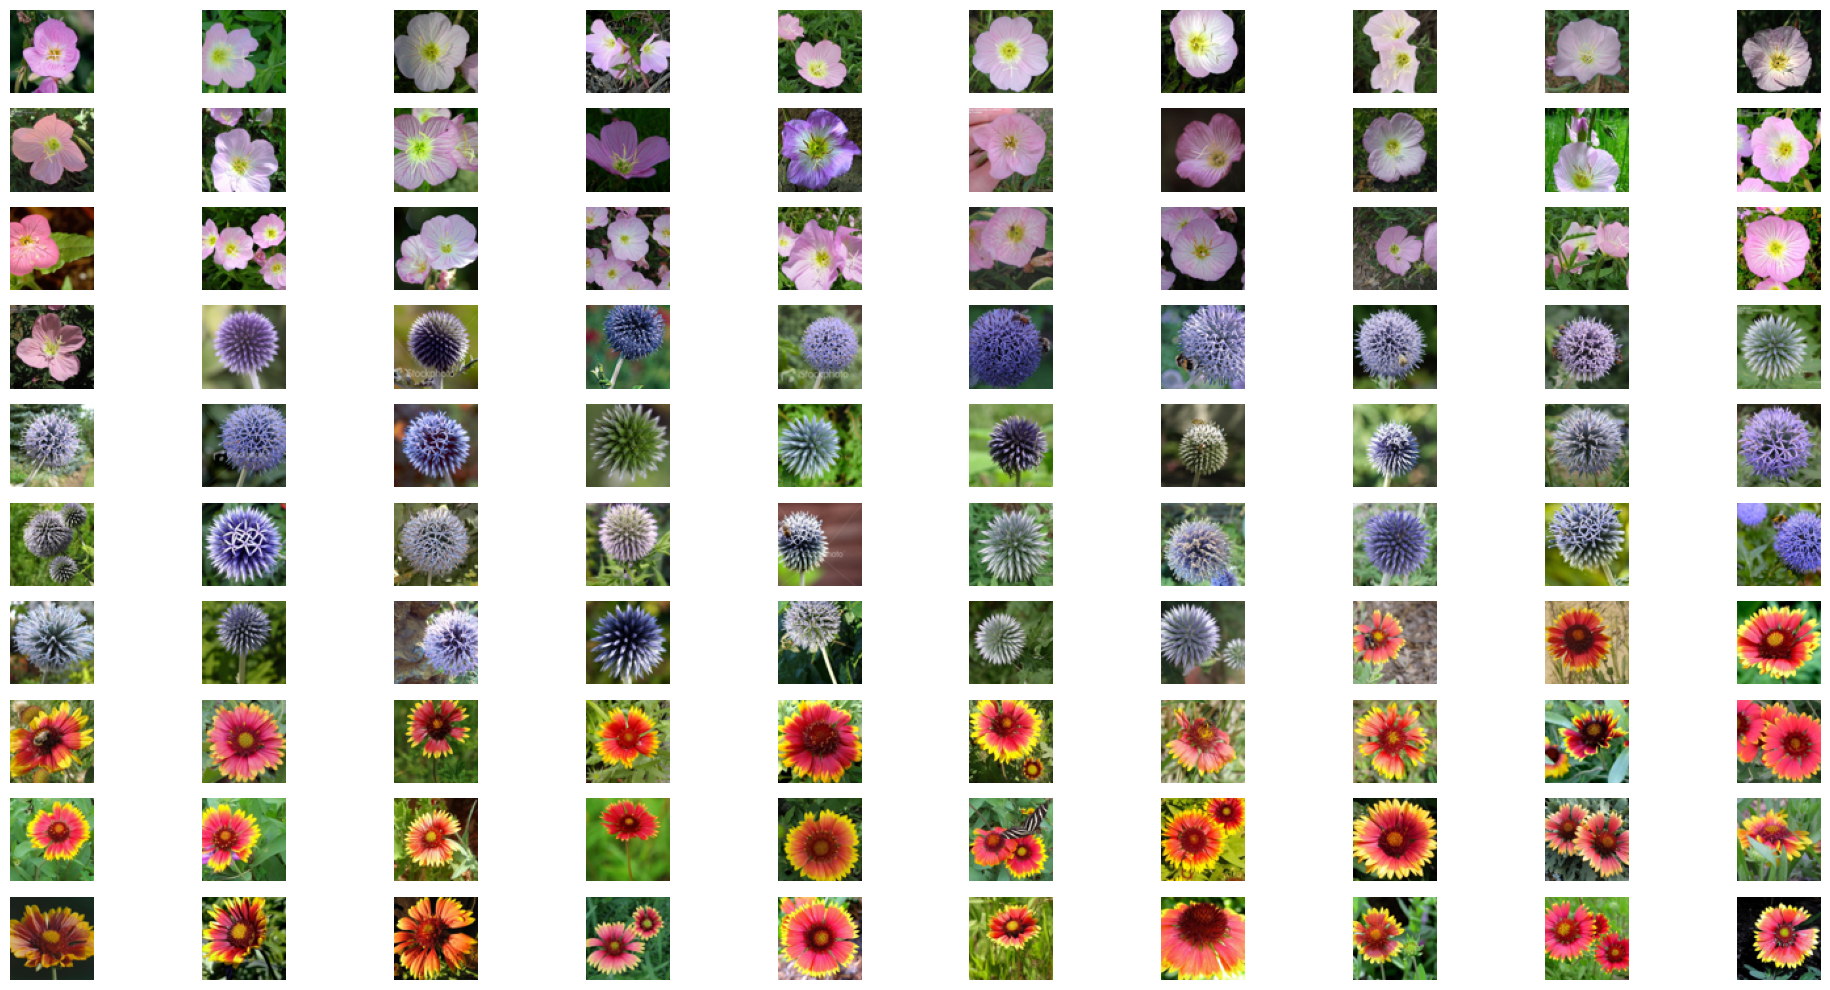

In [ ]:
# Visualizar algunas flores.
fig, ejes = plt.subplots(10, 10, figsize=(20, 10))
for eje, imagen in zip(ejes.flat, imagenes[:100]):
    eje.imshow(imagen)
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
np.shape(imagenes)

(100, 64, 64, 3)

In [ ]:
rng = np.random.default_rng(42)

# 1. Barajar y separar las imágenes.
indices = rng.permutation(len(imagenes))
corte = int(0.8 * len(imagenes))

entrenamiento = imagenes[indices[:corte]]
test = imagenes[indices[corte:]]

print("Entrenamiento:", entrenamiento.shape)
print("Test:", test.shape)

# 2. Perturbar todos los píxeles y canales.
sigma = 0.20  # Intensidad del ruido; las imágenes están entre 0 y 1.

def perturbar(X, sigma):
    ruido = rng.normal(size=X.shape).astype("float32")
    return X + sigma * ruido, ruido

entrenamiento_perturbado, ruido_train = perturbar(entrenamiento, sigma)
test_perturbado, ruido_test = perturbar(test, sigma)

# 3. Comparar una imagen antes y después.
i = 0

fig, ejes = plt.subplots(1, 2, figsize=(6, 3))

ejes[0].imshow(entrenamiento[i])
ejes[0].set_title("Original")

# Recortamos a [0, 1] únicamente para visualizar.
ejes[1].imshow(np.clip(entrenamiento_perturbado[i], 0, 1))
ejes[1].set_title(f"Perturbada: σ = {sigma}")

for eje in ejes:
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers

keras.utils.set_random_seed(42)

modelo = keras.Sequential([
    keras.Input(shape=entrenamiento.shape[1:]),

    layers.Conv2D(
        32, kernel_size=3, padding="same", activation="relu"
    ),
    layers.Conv2D(
        32, kernel_size=3, padding="same", activation="relu"
    ),

    # Predecir el ruido de los tres canales RGB.
    layers.Conv2D(3, kernel_size=3, padding="same")
])

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

modelo.summary()

print("Entrada:", modelo.input_shape)
print("Salida:", modelo.output_shape)

NameError: name 'entrenamiento' is not defined

In [ ]:
sigma = 0.15
n_epocas = 20

perdidas_train = []
perdidas_test = []

# El test mantiene el mismo ruido durante toda la evaluación.
test_perturbado, ruido_test = perturbar(test, sigma)

for epoca in range(n_epocas):
    # Entrenamiento con ruido nuevo.
    entradas, ruido_real = perturbar(entrenamiento, sigma)

    historia = modelo.fit(
        entradas,
        ruido_real,
        epochs=1,
        batch_size=8,
        shuffle=True,
        verbose=0
    )

    mse_train = historia.history["loss"][0]

    # Evaluación: los pesos permanecen fijos.
    mse_test = modelo.evaluate(
        test_perturbado,
        ruido_test,
        batch_size=8,
        verbose=0
    )

    perdidas_train.append(mse_train)
    perdidas_test.append(mse_test)

    print(
        f"Época {epoca + 1:02d}/{n_epocas} | "
        f"Train: {mse_train:.4f} | Test: {mse_test:.4f}"
    )

# Graficar ambas curvas.
epocas = range(1, n_epocas + 1)


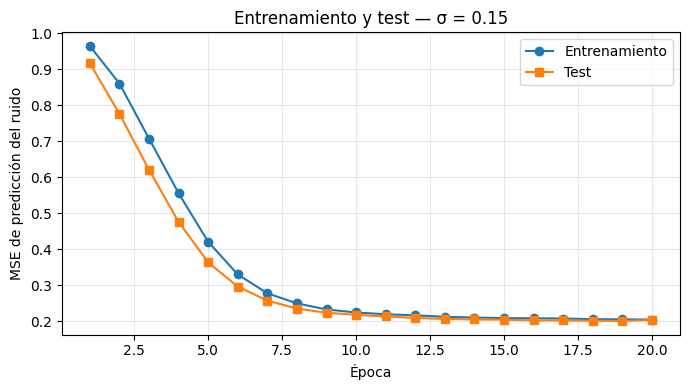

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(epocas, perdidas_train, "o-", label="Entrenamiento")
plt.plot(epocas, perdidas_test, "s-", label="Test")
plt.xlabel("Época")
plt.ylabel("MSE de predicción del ruido")
plt.title(f"Entrenamiento y test — σ = {sigma}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

MSE antes:   0.022501
MSE después: 0.004586


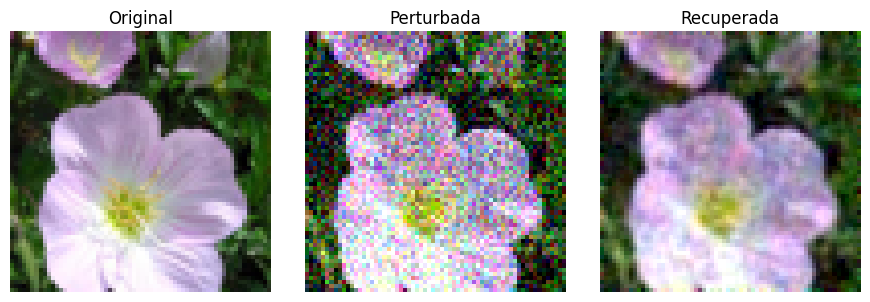

In [ ]:
# Predecir el ruido y restarlo.
ruido_predicho = modelo.predict(
    test_perturbado, batch_size=8, verbose=0
)

sigma=0.15
recuperadas = test_perturbado - sigma * ruido_predicho

# Comparar el error respecto a las imágenes originales.
mse_antes = np.mean((test_perturbado - test)**2)
mse_despues = np.mean((recuperadas - test)**2)

print(f"MSE antes:   {mse_antes:.6f}")
print(f"MSE después: {mse_despues:.6f}")

# Visualizar una flor.
i = 3
fig, ejes = plt.subplots(1, 3, figsize=(9, 3))

comparacion = [
    (test[i], "Original"),
    (test_perturbado[i], "Perturbada"),
    (recuperadas[i], "Recuperada")
]

for eje, (imagen, titulo) in zip(ejes, comparacion):
    eje.imshow(np.clip(imagen, 0, 1))  # Recorte solo para mostrar.
    eje.set_title(titulo)
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:


n_imagenes = 9
n_pasos = 5000
rng_generacion = np.random.default_rng(123)

# Paso pequeño de Langevin.
h = np.float32(0.005 * sigma**2)
amplitud = np.float32(np.sqrt(2 * h))

# Inicialización independiente de las flores originales.
forma = tuple(modelo.input_shape[1:])
generadas = rng_generacion.uniform(
    0, 1, size=(n_imagenes, *forma)
).astype("float32")

# Guardar la evolución de la primera imagen.
evolucion = {0: generadas[0].copy()}
guardar_en = {50, 100, 250, n_pasos}

# Inferencia con tu backend Torch: los pesos permanecen fijos.
with torch.no_grad():
    for paso in range(1, n_pasos + 1):

        # La red predice epsilon, no sigma * epsilon.
        ruido_predicho = keras.ops.convert_to_numpy(
            modelo(generadas, training=False)
        )

        score = -ruido_predicho / sigma

        # Ruido nuevo para la dinámica de Langevin.
        z = rng_generacion.normal(
            size=generadas.shape
        ).astype("float32")

        generadas = generadas + h * score + amplitud * z

        # Mantener los valores sin recortar durante la dinámica.
        if paso in guardar_en:
            evolucion[paso] = generadas[0].copy()

        if paso % 100 == 0:
            if not np.isfinite(generadas).all():
                raise FloatingPointError(
                    "La dinámica diverge. Reduce el valor de h."
                )
            print(f"Paso {paso}/{n_pasos}")



Paso 100/5000
Paso 200/5000
Paso 300/5000
Paso 400/5000
Paso 500/5000
Paso 600/5000
Paso 700/5000
Paso 800/5000
Paso 900/5000
Paso 1000/5000
Paso 1100/5000
Paso 1200/5000
Paso 1300/5000
Paso 1400/5000
Paso 1500/5000
Paso 1600/5000
Paso 1700/5000
Paso 1800/5000
Paso 1900/5000
Paso 2000/5000
Paso 2100/5000
Paso 2200/5000
Paso 2300/5000
Paso 2400/5000
Paso 2500/5000
Paso 2600/5000
Paso 2700/5000
Paso 2800/5000
Paso 2900/5000
Paso 3000/5000
Paso 3100/5000
Paso 3200/5000
Paso 3300/5000
Paso 3400/5000
Paso 3500/5000
Paso 3600/5000
Paso 3700/5000
Paso 3800/5000
Paso 3900/5000
Paso 4000/5000
Paso 4100/5000
Paso 4200/5000
Paso 4300/5000
Paso 4400/5000
Paso 4500/5000
Paso 4600/5000
Paso 4700/5000
Paso 4800/5000
Paso 4900/5000
Paso 5000/5000


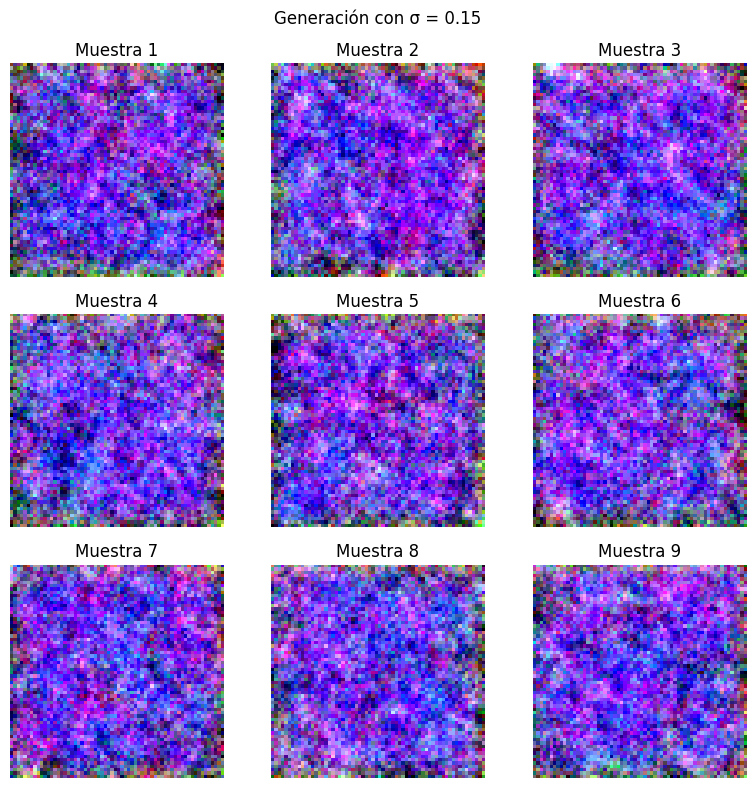

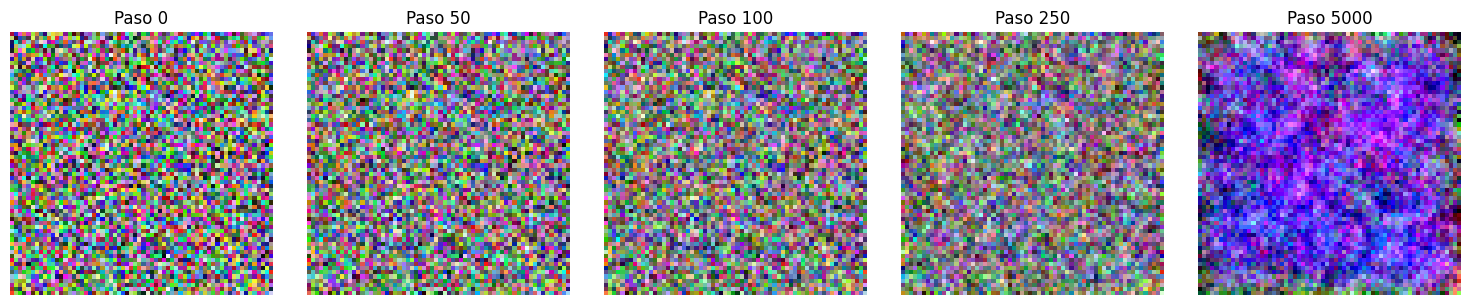

In [ ]:
# Mostrar las nueve imágenes finales.
fig, ejes = plt.subplots(3, 3, figsize=(8, 8))

for i, eje in enumerate(ejes.flat):
    eje.imshow(np.clip(generadas[i], 0, 1))
    eje.set_title(f"Muestra {i + 1}")
    eje.axis("off")

fig.suptitle(f"Generación con σ = {float(sigma):.2f}")
plt.tight_layout()
plt.show()

# Mostrar cómo evolucionó la primera imagen.
fig, ejes = plt.subplots(
    1, len(evolucion), figsize=(3 * len(evolucion), 3)
)

for eje, (paso, imagen) in zip(ejes, evolucion.items()):
    eje.imshow(np.clip(imagen, 0, 1))
    eje.set_title(f"Paso {paso}")
    eje.axis("off")

plt.tight_layout()
plt.show()


Tarea laboratorio es : Implementar una red tipo Unet, para generar imagenes con una mejor aproximación